# Case Study 02 — JPM, a quiet mid-June session (grade day 2025-06-11)

**Type:** no-catalyst day  ·  **Ticker:** JPM  ·  **asof:** 2025-06-11

Runs the full pipeline (`src/graph.py`) for this one signal-day and shows every stage. Companion to [`notebooks/walkthrough.ipynb`](walkthrough.ipynb), which explains the machinery in detail.

## Why this case

The counterpoint to both earnings cases: **a day with no material news**. JPMorgan
doesn't report until mid-July; the overnight coverage is routine analyst notes and
a generic "banks await CPI" market wrap. There is no catalyst for narrative to
read.

The question this case exists to answer: **when narrative correctly abstains, does
the structural signal alone carry any information — or is a no-catalyst day just
noise for both sides?** If narrative adds value only by staying quiet here, that's
still a finding.

In [1]:
import sys, os, json, shutil, pathlib
sys.path.insert(0, "..")
DEMO_LOG = pathlib.Path("_out/case_jpm_2025-06-11").resolve()
if DEMO_LOG.exists(): shutil.rmtree(DEMO_LOG)
DEMO_LOG.mkdir(parents=True)
os.environ["NARB_LOG_DIR"] = str(DEMO_LOG)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 100)
from src.llm import have_key
TICKER, ASOF = "JPM", "2025-06-11"
print("real LLM:", have_key(), " (mock mode if False)")

real LLM: False  (mock mode if False)


## 1 · Data — the no-lookahead cut

source cache · 120 bars · 2024-12-16 -> 2025-06-10


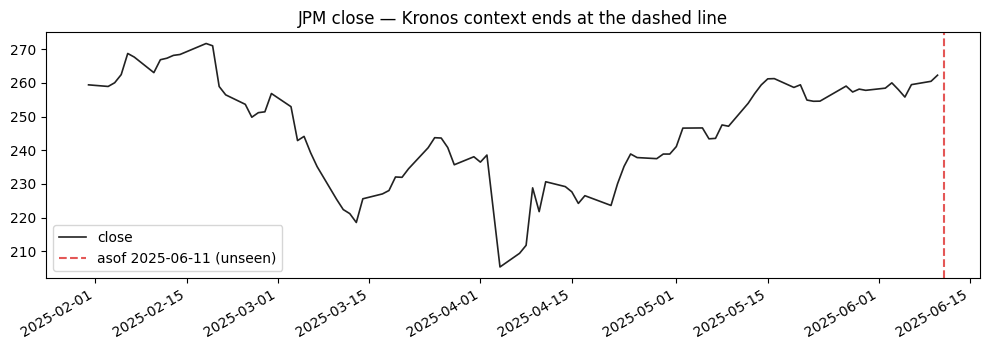

In [2]:
from src.data import load_context, load_actual
pl = load_context(TICKER, ASOF)
print(f"source {pl.source} · {len(pl.df)} bars · {pl.df.index.min().date()} -> {pl.last_context_date.date()}")
assert pl.last_context_date < pd.Timestamp(ASOF)
ax = pl.df["close"].iloc[-90:].plot(figsize=(10,3.6), color="#222", lw=1.2)
ax.axvline(pd.Timestamp(ASOF), color="#e45756", ls="--", label=f"asof {ASOF} (unseen)")
ax.set_title(f"{TICKER} close — Kronos context ends at the dashed line"); ax.legend(); plt.tight_layout()

## 2 · Structure — Kronos distribution

/Users/isaac/Desktop/narrative arb/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


median +0.33%  P(up) 69%  dispersion 1.03%  strength +0.32
5-95 envelope: [-1.48%, +1.98%]


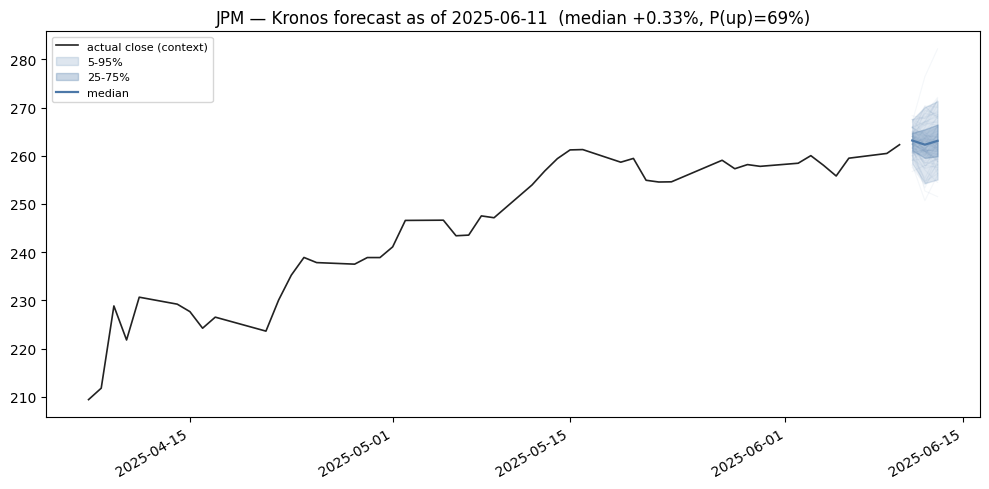

In [3]:
from src.kronos_infer import forecast, fan_chart
fc = forecast(pl)
q = fc.ret_quantiles()
print(f"median {fc.median_ret*100:+.2f}%  P(up) {fc.p_up:.0%}  dispersion {fc.std_ret*100:.2f}%  strength {fc.strength:+.2f}")
print("5-95 envelope:", f"[{q[0.05]*100:+.2f}%, {q[0.95]*100:+.2f}%]")
_ = fan_chart(fc, context_bars=45)

## 3 · Headlines sub-agent (price-blind)

In [4]:
from src.headlines_agent import get_headlines
hs = get_headlines(TICKER, ASOF)
print("mode:", hs["mode"], "| no_news:", hs["no_news"])
for n in hs["notes"]: print("  -", n)
pd.DataFrame(hs["headlines"])[["source","published","title"]] if hs["headlines"] else "— nothing material —"

mode: curated | no_news: False
  - loaded 2 curated headlines
  - dedupe: 2 -> 2
  - materiality: kept 1/2 — Headline 1 is a genuine analyst action with a specific thesis (NII trends, capital returns) tied to JPMorgan, which PMs may view as incrementally material. Headline 2 is a generic market recap noting no company-specific catalysts and macro-wide waiting on CPI/Fed, not specific to JPM, so it's dropped.
  - FINAL: 1 material headlines


,source,published,title
0,routine analyst note,2025-06-10,"Analyst maintains Overweight rating on JPMorgan, nudges price target"


## 4 · Narrative score

In [5]:
from src.narrative import score_narrative
sc = score_narrative(TICKER, hs["headlines"], ASOF)
print(json.dumps(sc.to_dict(), indent=2))

{
  "ticker": "JPM",
  "asof": "2025-06-11",
  "direction": "neutral",
  "conviction": 2,
  "rationale": "The only headline is a routine analyst reiteration of an existing Overweight rating with a minor price target tweak and no change to estimates. This is recycled sell-side commentary rather than a new catalyst like earnings, guidance changes, or regulatory action, so it carries little incremental information for the stock.",
  "key_drivers": [
    "Analyst reiterates Overweight rating",
    "Minor price target adjustment",
    "No change to estimates"
  ],
  "material_news": false,
  "headline_count": 1,
  "llm_contaminated": true,
  "model": "claude-sonnet-5",
  "mocked": false
}


## 5 · Divergence verdict

In [6]:
from src.divergence import assess
div = assess(sc, fc, brief=True)
print(f"structure dir {div.struct_dir:+d} ({div.struct_median*100:+.2f}%)  |  "
      f"narrative dir {div.narr_dir:+d} (conv {sc.conviction})")
print(f"P(move in narrative's direction | structure) = {div.p_narr_direction:.0%}")
print(f"\n==> {div.divergence_type}\n\n{div.brief}")

structure dir +1 (+0.33%)  |  narrative dir +0 (conv 2)
P(move in narrative's direction | structure) = 69%

==> aligned

STRUCTURE points modestly higher: median close-to-close +0.33%, P(up) 69%, strength +0.32 sd, with a 5-95% band of -1.48% to +1.98%. NARRATIVE is neutral, conviction 2/10 from a single headline — a routine analyst reiteration of an existing Overweight rating with a minor price-target tweak and no estimate changes, judged to carry little incremental information. The two are classified as aligned only in the sense that narrative offers no direction to conflict with; it does not endorse the structural tilt (69% probability under structure). Resolution at the close: whether JPM finishes near or above the +0.33% median, within the given band, would confirm the structural read, while a flat or negative close would be consistent with narrative's low-conviction, no-catalyst view.


## 6 · Lock + grade at the close

In [7]:
from src.graph import run_ticker, _summary_row
from src.evaluate import run as run_eval
from src.store import joined
run_ticker(TICKER, ASOF, allow_replace=True)
run_eval(ASOF)
row = joined().query("ticker==@TICKER and asof==@ASOF").iloc[0]
a = load_actual(TICKER, ASOF)
print(f"realised close-to-close: {a.ret*100:+.2f}%")
row[["ret","kronos_q05","kronos_q50","kronos_q95","inside_envelope",
     "dir_match_struct","dir_match_narr","divergence_type","divergence_outcome"]]

realised close-to-close: -0.17%


ret                  -0.001676
kronos_q05           -0.014834
kronos_q50            0.003319
kronos_q95            0.019795
inside_envelope           True
dir_match_struct         False
dir_match_narr           False
divergence_type        aligned
divergence_outcome         n/a
Name: 0, dtype: object

Text(0.5, 1.0, 'JPM — Kronos forecast as of 2025-06-11  (median +0.33%, P(up)=69%)\nactual -0.17%  ->  inside the 5-95 envelope')

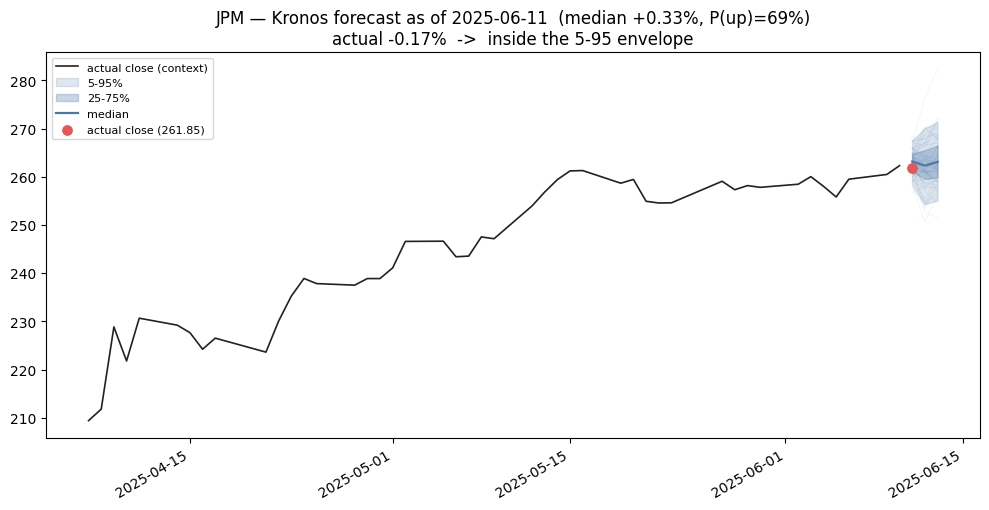

In [8]:
_ = fan_chart(fc, actual_close=a.actual_close, context_bars=45)
plt.gca().set_title(plt.gca().get_title() +
    f"\nactual {a.ret*100:+.2f}%  ->  {'inside' if row['inside_envelope'] else 'OUTSIDE'} the 5-95 envelope")

## 7 · Reading

### Reading this case

JPM barely moved (see the grade cell). With no catalyst, the headline sub-agent
should have filtered the routine coverage down to nothing material and the
narrative score should be neutral / low-conviction — narrative correctly abstains.

That makes the row a test of **Kronos's calibration with narrative silent**: does
the actual close land inside the 5–95 envelope, and is the envelope an honest
width for a day the model has no particular view? A near-zero realised move
sitting comfortably mid-envelope is the expected, boring, *good* outcome.

Part 2 reports envelope coverage separately for catalyst and no-catalyst days —
if the model is only well-calibrated on quiet days, that itself is worth knowing.


*(the numbers above are filled from this run; the narrative take assumes the real LLM scorer — re-run with `ANTHROPIC_API_KEY` set if you see `[MOCK]`.)*